In [2]:
import sys
import os

model_upgrading_path = os.path.join("..","src")
sys.path.append(model_upgrading_path)

In [1]:
# moduel
from my_package.data.select_dataset_all import get_all_dataframe_from_database
import my_package.time_series as time

# basic
import pandas as pd
import numpy as np
import pickle

# visualize
import matplotlib.pyplot as plt  

# learning
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

ModuleNotFoundError: No module named 'my_package'

<span style="color: blue; font-size: 14px; font-weight: bold; background-color: #f0f0f0; padding: 5px; border-radius: 5px;">
    실행
</span>

In [56]:
# goals: 특정 배 찾기
#'MASAN TEST150'

In [57]:
# goals: 데이터 생성 

data = time.create_electrode_data()

In [59]:
# goals: 데이터 처리

ship_name = 'AKRA'

ship_id = ship_id = time.find_ship(ship_name)[0]

df = time.preprocess_data(data,ship_id)

df = time.generate_moving_average(df,250)

In [60]:
# goals: 시간 기준 데이터 그룹화 ( 효율 평균 )

group = df[['DATA_TIME','Moving_Average']].groupby('DATA_TIME').mean().reset_index()

In [61]:
# datetime 형식으로 변환
group['DATA_TIME'] = pd.to_datetime(group['DATA_TIME'])

# datetime을 인덱스로 설정
group.set_index('DATA_TIME', inplace=True)

# 6시간 단위로 리샘플링 (6H = 6시간)
# 여기서 'mean'은 6시간 동안의 평균을 계산하는 방식
df_resampled = group.resample('3H').mean()
df_resampled = df_resampled.dropna()
df_resampled.reset_index(inplace=True)

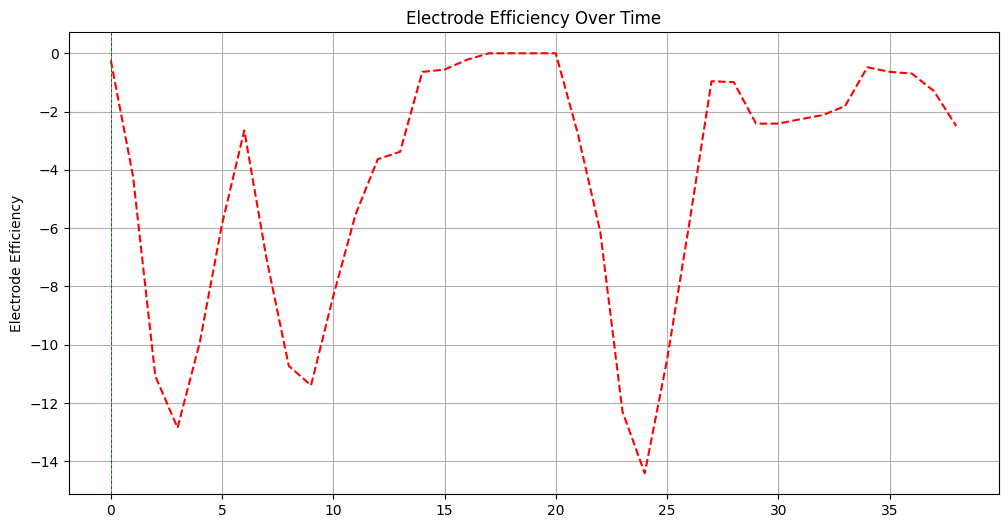

In [62]:
# goals: 시각화를 이용한 탐색적 데이터 분석

time.plot_time_series(df_resampled)

In [48]:
# 학습 데이터 생성
#X_train,X_test,y_train,y_test,scaler = time.make_train_dataset(df_resampled,10)

# 모델 개발
#lstm_model = time.train_lstm_obj(X_train,y_train, 10)

모델이 성공적으로 'time_model_250_3h_10.pkl'에서 로드되었습니다.
20/20 [==============================] - 0s 5ms/step


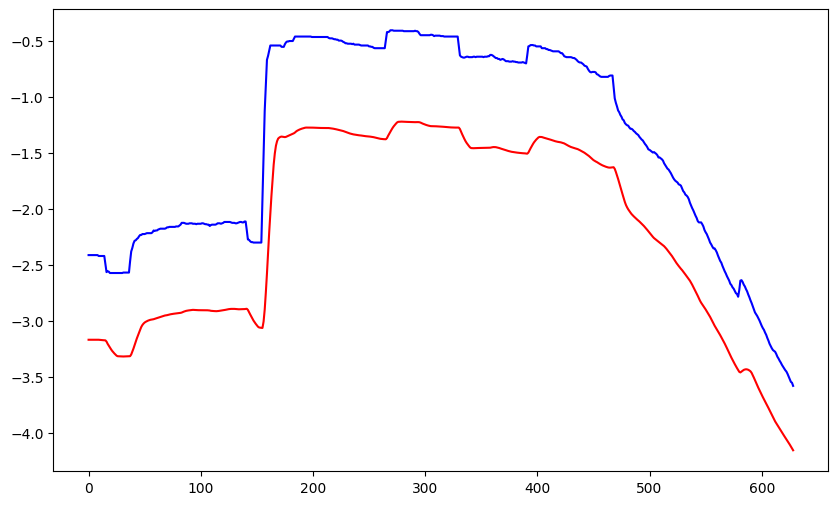

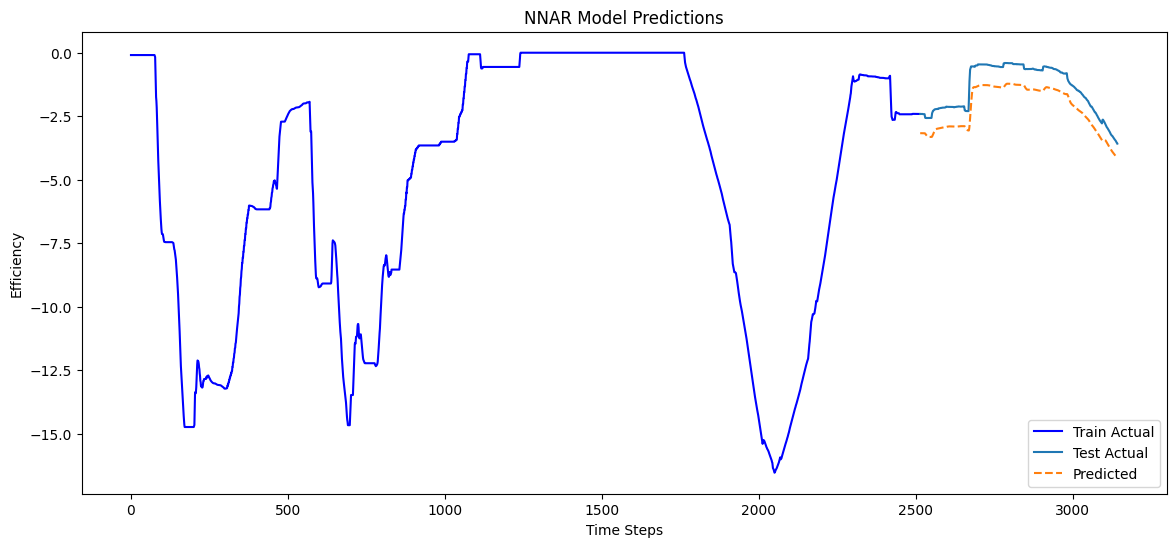

Root Mean Squared Error (RMSE): 0.7897662984837495


In [63]:
# goals: 모델 학습

# 학습 데이터 생성
X_train,X_test,y_train,y_test,scaler = time.make_train_dataset(group, 10)

# 모델 개발
#lstm_model = time.train_lstm_obj(X_train,y_train,200)

lstm_model = time.load_model_from_pickle('time_model_250_3h_10.pkl')

predictions = lstm_model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(10,6))
plt.plot(y_test_rescaled, label = 'Train Actual', color='blue')
plt.plot(predictions, label = 'Prediction', color='red')

# 결과 시각화
y_test_rescaled, predictions = time.plot_predict_values(lstm_model,X_test,y_train,y_test,scaler)

# 평가 지표 생성
time.calculate_evaluation(y_test_rescaled, predictions)

In [23]:
def make_step_by_step_prediction(scaled_data,model,turns):

    # 단계별 예측을 통한 6000분 후 예측
    # 초기 입력 데이터로 마지막 10분 데이터 사용
    # 설정
    # 동안의 데이터를 사용하여 예측

    predicted_values = []
    current_sequence = scaled_data[-1:]  # 마지막 time_steps 분간의 데이터

    for i in range(turns):
    
        # LSTM 모델은 (배치 크기, 타임스텝, 피처 수) 형태의 데이터를 입력받아야 하므로,
        # current_sequence의 i번째 타임스텝을 모델에 입력 (즉, (1, 100, 1) 형태로 변환)
        input_sequence = current_sequence[i].reshape((1,scaled_data.shape[1],1))  # (1, 100, 1)
        
        # 다음 값을 예측
        predicted_value = model.predict(input_sequence)
        
        # 예측된 값을 predicted_values에 추가
        predicted_values.append(predicted_value.item())

        # 예측된 값을 현재 시퀀스에 추가하고, 맨 앞의 값을 제거
        predicted_value_reshaped = np.array(predicted_value).reshape(1, 1)  # (1, 1)으로 변환
        
         # 마지막 시퀀스의 첫 번째 값을 제거하고, 예측된 값을 끝에 추가
        last_sequence = current_sequence[-1]  # 마지막 시퀀스 (크기: (100, 1))
        
        # new_value를 (1, 100, 1) 형식으로 변환
        new_value_reshaped = np.append(last_sequence[1:], predicted_value).reshape(1,scaled_data.shape[1],1)
        
        # current_sequence의 끝에 new_value_reshaped를 추가 (concatenate 사용)
        current_sequence = np.concatenate((current_sequence, new_value_reshaped), axis=0)

        
    # 2000분 후 예측된 마지막 값 출력
    
    return current_sequence, predicted_values

In [24]:
current_sequence, predicted_values = make_step_by_step_prediction(X_train,lstm_model,100)

1/1 [==============================] - 0s 27ms/step


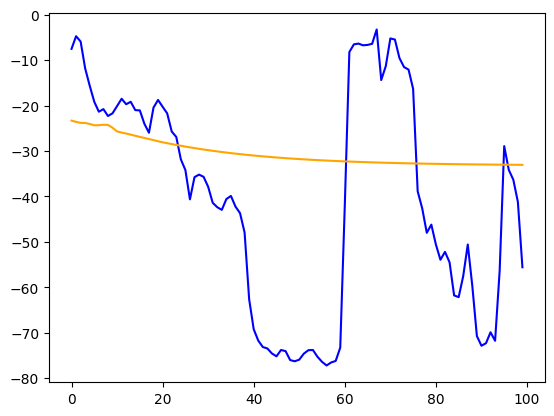

In [38]:
predictions = scaler.inverse_transform(np.array(predicted_values).reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test[:100].reshape(-1, 1))

plt.plot(y_test_rescaled, label = 'Train Actual', color='blue')
plt.plot(predictions, label = 'Prediction', color='orange')

In [15]:
# 피클 파일로 모델 저장

# 모델을 피클 파일로 저장
model_name = 'time_model_250_3h_10.pkl'

time.save_model_from_pickle(model_name, lstm_model)

모델이 time_model_250_3h_10.pkl.pkl 파일로 저장되었습니다.


In [ ]:
# 파일 경로를 지정하여 모델을 로드
loaded_model = load_model_from_pickle('time_model.pkl')

# 모델 사용 예시
if loaded_model:
    # 로드한 모델을 사용하여 예측
    # 예: predictions = loaded_model.predict(X_test)
    pass